In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")

# Load the Luxury Retail dataset
df = pd.read_csv('/kaggle/input/datasets/gyaanluthria/luxury-sales/Luxury_Retail_Financials.csv')

print("--- DATA STRUCTURE ---")
df.info()

print("\n--- STATISTICAL SUMMARY ---")
display(df.describe())

print("\n--- CATEGORY COUNTS (Top Product Lines) ---")
print(df['Product_Line'].value_counts())

--- DATA STRUCTURE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction_ID           10000 non-null  int64  
 1   Purchase_Date            10000 non-null  object 
 2   Boutique_City            10000 non-null  object 
 3   Product_Line             10000 non-null  object 
 4   Customer_Tier            10000 non-null  object 
 5   Traffic_Source           10000 non-null  object 
 6   Units_Sold               10000 non-null  int64  
 7   Unit_Retail_Price        10000 non-null  int64  
 8   Unit_Manufacturing_Cost  10000 non-null  int64  
 9   Net_Revenue              10000 non-null  int64  
 10  Total_Cost               10000 non-null  int64  
 11  Gross_Profit             10000 non-null  int64  
 12  Profit_Margin_Pct        10000 non-null  float64
dtypes: float64(1), int64(7), object(5)
memory usage: 1015.

,Transaction_ID,Units_Sold,Unit_Retail_Price,Unit_Manufacturing_Cost,Net_Revenue,Total_Cost,Gross_Profit,Profit_Margin_Pct
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5.005000e+06,1.196400,6997.111600,1746.974800,8337.619700,2082.16110,6255.458600,75.037560
std,2.886896e+03,0.503441,4840.206753,1302.708821,7106.014393,1883.77815,5368.596371,5.776036
min,5.000000e+06,1.000000,315.000000,47.000000,315.000000,49.00000,206.000000,65.000000
25%,5.002500e+06,1.000000,3188.000000,700.000000,3237.000000,737.00000,2411.000000,70.100000
50%,5.005000e+06,1.000000,7684.500000,1302.500000,7944.500000,1692.00000,5814.000000,75.000000
75%,5.007499e+06,1.000000,11886.250000,2734.000000,12453.250000,2967.00000,9280.000000,80.000000
max,5.009999e+06,3.000000,14998.000000,5203.000000,44772.000000,15075.00000,37653.000000,85.200000



--- CATEGORY COUNTS (Top Product Lines) ---
Product_Line
Designer Handbags    3555
Luxury Watches       2987
Fine Jewelry         2041
Haute Fragrance      1417
Name: count, dtype: int64


**Initial Observation:** The dataset contains 10,000 records with perfectly clean data (0 missing values). The average Gross Profit per transaction is $6,255. New York is our highest-volume boutique city, and Designer Handbags are our most frequently sold product line.

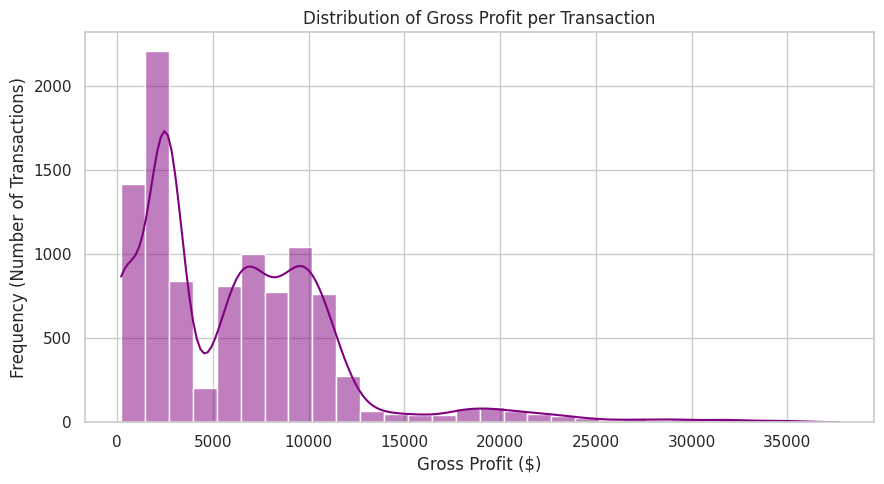

In [2]:
plt.figure(figsize=(9, 5))
# Histogram for Gross Profit
sns.histplot(df['Gross_Profit'], bins=30, kde=True, color='purple')
plt.title('Distribution of Gross Profit per Transaction')
plt.xlabel('Gross Profit ($)')
plt.ylabel('Frequency (Number of Transactions)')
plt.tight_layout()
plt.show()

**Histogram Observation:** The profit distribution is right-skewed. Most transactions generate introductory luxury returns under $10,000, but there is a long tail of rare, ultra-luxury transactions extending past $35,000 in profit.

/tmp/ipykernel_58/3216059285.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product_Line', y='Gross_Profit', data=df, palette='Set2')


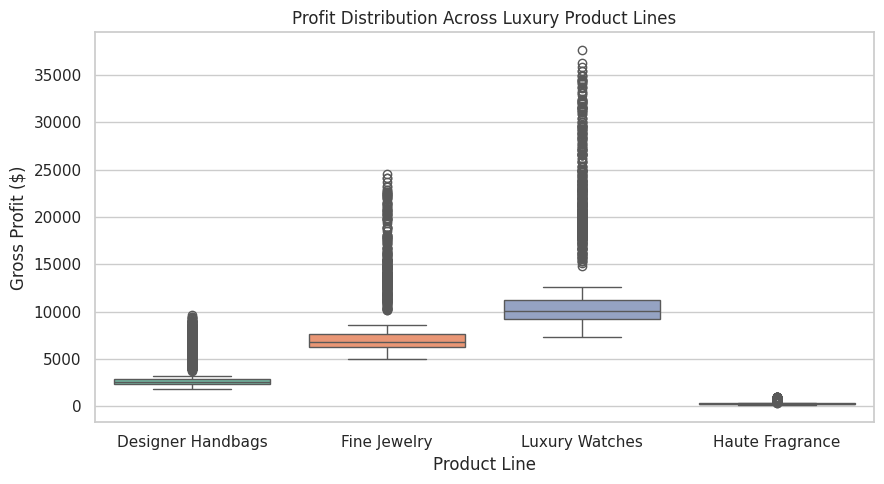

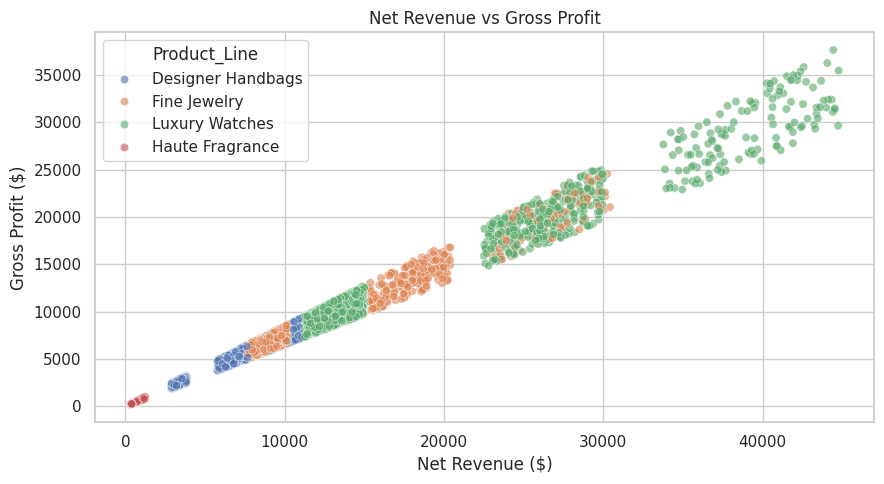

In [4]:
# Boxplot Diagram
plt.figure(figsize=(9, 5))
sns.boxplot(x='Product_Line', y='Gross_Profit', data=df, palette='Set2')
plt.title('Profit Distribution Across Luxury Product Lines')
plt.xlabel('Product Line')
plt.ylabel('Gross Profit ($)')
plt.tight_layout()
plt.show()

# Scatterplot Diagram
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Net_Revenue', y='Gross_Profit', hue='Product_Line', data=df, alpha=0.6)
plt.title('Net Revenue vs Gross Profit')
plt.xlabel('Net Revenue ($)')
plt.ylabel('Gross Profit ($)')
plt.tight_layout()
plt.show()

**Bivariate Observations:** * **Boxplot:** While Designer Handbags have the highest volume, Luxury Watches and Fine Jewelry generate significantly higher median profits and contain the most lucrative outlier deals.
* **Scatterplot:** There is a strict positive relationship between Revenue and Profit. The data separates into distinct "bands," showing that different product categories operate on very specific, fixed profit margins.

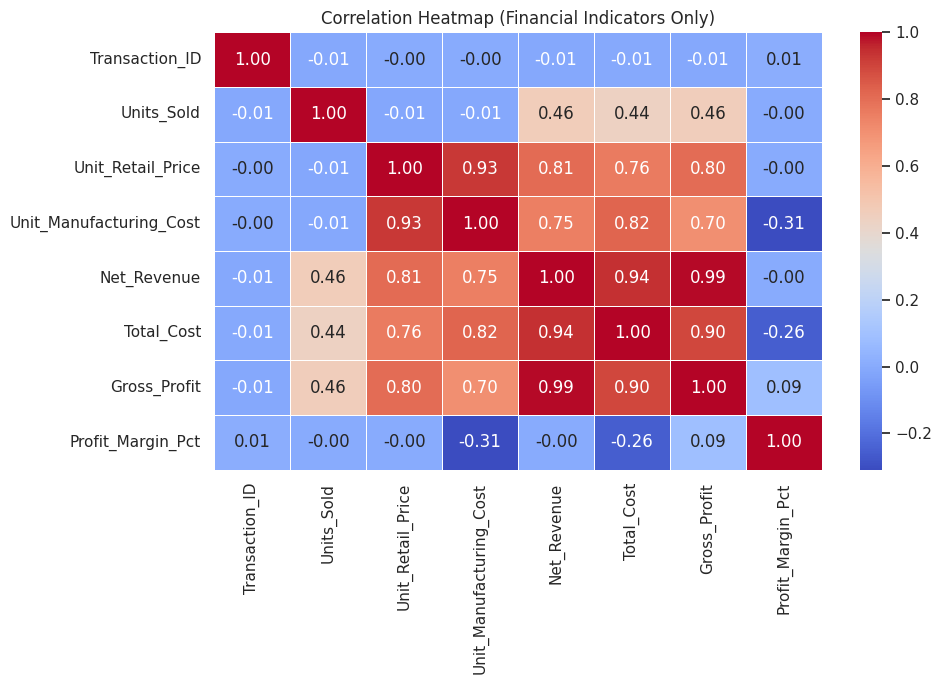

In [5]:
# Select only numeric columns to prevent data type errors
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Financial Indicators Only)')
plt.tight_layout()
plt.show()

**Multivariate Observation:** The heatmap reveals that Gross Profit correlates almost perfectly with Net Revenue (0.99), but has a surprisingly weak correlation with Units Sold (0.46).

### Final Summary of Findings
1. **Data Quality:** The dataset is incredibly robust with exactly zero missing values to clean.
2. **Product Profitability:** While Designer Handbags and Haute Fragrance drive high transaction volumes, Luxury Watches and Fine Jewelry are the true drivers of massive profit spikes.
3. **Financial Correlations:** Selling high-margin products is far more important to the bottom line than simply pushing a high volume of units (as proven by the weak 0.46 correlation between Units Sold and Gross Profit).